# Notebook 04 — Treino do Modelo: Swin Transformer Tiny

Este notebook implementa o treino de um **Swin Transformer Tiny** com Transfer Learning sobre o dataset MIQR-CC pré-processado (Notebooks 01 e 02).

O **Swin Transformer** (*Shifted Window Transformer*) foi desenvolvido pela **Microsoft em 2021** e representa o estado da arte em Visão Computacional baseado em Transformers. Ao contrário das CNNs (como DenseNet ou EfficientNet), processa a imagem dividindo-a em *patches* e aplica mecanismos de **auto-atenção** (self-attention) dentro de janelas deslizantes, capturando dependências de longo alcance. A variante **Tiny** oferece um excelente equilíbrio entre desempenho e eficiência computacional.

**Pipeline:**
1. Autenticar e configurar o Weights & Biases (WandB)
2. Carregar os CSVs do split (Train / Val / Test)
3. Configurar pesos de classes para lidar com o desequilíbrio
4. Definir Dataset e Transforms (224×224, normalização ImageNet)
5. Instanciar o modelo Swin Transformer Tiny com pesos pré-treinados em ImageNet
6. Treinar com estratégia de Fine-Tuning em 2 fases e registo no WandB
7. Avaliar no Test Set — F1-Score Macro, AUC-ROC e Matriz de Confusão

---


## 0. Login no WandB

Antes de executar este notebook pela primeira vez, autentique-se no Weights & Biases:
```bash
wandb login
```
Introduza a API Key quando solicitado. Este passo só é necessário **uma vez** por ambiente.


## 1. Importações

In [9]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import timm                          # Biblioteca com os modelos mais modernos (inclui Swin)
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
import torch.nn.functional as F

import wandb

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print('Importações concluídas!')

Dispositivo: cpu
Importações concluídas!


## 2. Carregar os CSVs do Split (Fase 1)

In [10]:
DATA_DIR = '../data/'
CSV_DIR  = '../data/processed/'

df_train = pd.read_csv(os.path.join(CSV_DIR, 'train_split.csv'))
df_val   = pd.read_csv(os.path.join(CSV_DIR, 'val_split.csv'))
df_test  = pd.read_csv(os.path.join(CSV_DIR, 'test_split.csv'))

# Classes ordenadas alfabeticamente
class_names = sorted(df_train['Label'].unique().tolist())
num_classes = len(class_names)
label2idx   = {label: i for i, label in enumerate(class_names)}
idx2label   = {i: label for label, i in label2idx.items()}

print(f'Classes ({num_classes}): {class_names}')
print(f'Mapeamento: {label2idx}')
print(f'\nDimensões do dataset:')
print(f'  Treino:    {len(df_train)} imagens')
print(f'  Validação: {len(df_val)} imagens')
print(f'  Teste:     {len(df_test)} imagens')
print(f'  Total:     {len(df_train)+len(df_val)+len(df_test)} imagens')

print('\nDistribuição do Treino:')
dist = df_train['Label'].value_counts()
for cls, count in dist.items():
    print(f'  {cls}: {count} ({100*count/len(df_train):.1f}%)')

Classes (4): ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']
Mapeamento: {'Biliary Leaks': 0, 'Lithiasis': 1, 'Normal': 2, 'Stricture': 3}

Dimensões do dataset:
  Treino:    1067 imagens
  Validação: 234 imagens
  Teste:     267 imagens
  Total:     1568 imagens

Distribuição do Treino:
  Lithiasis: 505 (47.3%)
  Stricture: 255 (23.9%)
  Normal: 197 (18.5%)
  Biliary Leaks: 110 (10.3%)


## 3. Class Weights (Lidar com Desequilíbrio de Classes)

In [11]:
y_train = df_train['Label'].map(label2idx).values

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=y_train
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print('Pesos calculados por classe (quanto mais alto = mais raro):')
for cls, w in zip(class_names, class_weights):
    bar = '█' * int(w * 5)
    print(f'  {cls:12s}: {w:.4f}  {bar}')

Pesos calculados por classe (quanto mais alto = mais raro):
  Biliary Leaks: 2.4250  ████████████
  Lithiasis   : 0.5282  ██
  Normal      : 1.3541  ██████
  Stricture   : 1.0461  █████


## 4. Dataset e Transforms

As imagens em `data/processed/` já foram sujeitas a CLAHE e normalização no Notebook 02.  
O Swin Transformer usa imagens 224×224 com normalização ImageNet.

In [12]:
IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transforms de Treino (com Data Augmentation)
train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.1),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transforms de Validação/Teste (sem augmentation)
val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print(f'Transforms definidos para imagens {IMG_SIZE}x{IMG_SIZE}.')

Transforms definidos para imagens 224x224.


In [13]:
class ERCPDataset(Dataset):
    """Dataset MIQR-CC carregado a partir dos CSVs do split."""

    def __init__(self, df, data_dir, label2idx, transforms):
        self.df         = df.reset_index(drop=True)
        self.data_dir   = data_dir
        self.label2idx  = label2idx
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.data_dir, row['processed_image_path'])
        label    = self.label2idx[row['Label']]
        img      = Image.open(img_path).convert('RGB')
        img      = self.transforms(img)
        return img, label


BATCH_SIZE = 16   # Reduz para 8 se deres Out of Memory

train_dataset = ERCPDataset(df_train, DATA_DIR, label2idx, train_transforms)
val_dataset   = ERCPDataset(df_val,   DATA_DIR, label2idx, val_transforms)
test_dataset  = ERCPDataset(df_test,  DATA_DIR, label2idx, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'DataLoaders criados (batch_size={BATCH_SIZE}):')
print(f'  Treino:    {len(train_loader)} batches  ({len(train_dataset)} imagens)')
print(f'  Validação: {len(val_loader)} batches  ({len(val_dataset)} imagens)')
print(f'  Teste:     {len(test_loader)} batches  ({len(test_dataset)} imagens)')

# Verificação rápida
imgs, labels = next(iter(train_loader))
print(f'\nShape de uma batch: imgs={imgs.shape}, labels={labels.shape}')

DataLoaders criados (batch_size=16):
  Treino:    67 batches  (1067 imagens)
  Validação: 15 batches  (234 imagens)
  Teste:     17 batches  (267 imagens)

Shape de uma batch: imgs=torch.Size([16, 3, 224, 224]), labels=torch.Size([16])


## 5. Criar o Modelo: Swin Transformer Tiny

O modelo **Swin Transformer Tiny** é carregado via `timm` com pesos pré-treinados em **ImageNet-1k**. É a variante mais eficiente da família Swin Transformer, combinando elevado desempenho com custo computacional moderado.


In [14]:
MODEL_NAME = 'swin_tiny_patch4_window7_224'

def build_swin(num_classes, freeze_backbone=True):
    """
    Cria um Swin Transformer Tiny pré-treinado.
    O timm substitui automaticamente a camada de saída (head) com num_classes.
    """
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=num_classes
    )

    if freeze_backbone:
        # Congelar todo o backbone (layers do Transformer)
        # Deixar apenas a head (classificador) treinar na Fase 1
        for name, param in model.named_parameters():
            if 'head' not in name:
                param.requires_grad = False

    # Adiciona dropout para reduzir o overfitting drasticamente
    model.head.drop = nn.Dropout(p=0.4)
    return model.to(device)


model = build_swin(num_classes, freeze_backbone=True)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Modelo: {MODEL_NAME}')
print(f'Parâmetros totais:     {total:,}')
print(f'Parâmetros treináveis: {trainable:,} ({100*trainable/total:.2f}%)')
print(f'\nCamada de saída (head):')
print(model.head)


Modelo: swin_tiny_patch4_window7_224
Parâmetros totais:     27,522,430
Parâmetros treináveis: 3,076 (0.01%)

Camada de saída (head):
ClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
  (drop): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=768, out_features=4, bias=True)
  (flatten): Identity()
)


## 6. Treino com WandB

Estratégia de Fine-Tuning em 2 fases:
- **Fase 1 (épocas 1–5):** Backbone congelado, só treina o classificador com `lr=1e-3`
- **Fase 2 (épocas 6+):** Backbone descongelado, fine-tuning completo com `lr=1e-5` e CosineAnnealing
- **Early Stopping** com paciência de 7 épocas sem melhoria no Val F1-Macro

In [15]:
def train_swin(
    wandb_project,
    wandb_entity,
    epochs_phase1=5,
    epochs_phase2=40,
    lr_phase1=1e-3,
    lr_phase2=3e-5,
    patience=10
):
    # ── WandB ──────────────────────────────────────────────────
    run = wandb.init(
        project=wandb_project,
        entity=wandb_entity,
        name='Swin-Transformer-Tiny',
        config={
            'model': MODEL_NAME,
            'img_size': IMG_SIZE,
            'batch_size': BATCH_SIZE,
            'epochs_phase1': epochs_phase1,
            'epochs_phase2': epochs_phase2,
            'lr_phase1': lr_phase1,
            'lr_phase2': lr_phase2,
            'optimizer': 'AdamW',
            'loss': 'CrossEntropyLoss (weighted)',
            'early_stopping_patience': patience,
            'num_classes': num_classes,
            'classes': class_names,
            'seed': SEED
        }
    )

    loss_fn   = nn.CrossEntropyLoss(weight=class_weights_tensor)
    os.makedirs('../models', exist_ok=True)
    save_path = './models/swin_tiny_best.pth'

    best_val_f1    = -1.0
    epochs_no_impr = 0

    # ── Função de uma época ────────────────────────────────────
    def run_epoch(model, loader, optimizer=None, training=True):
        model.train() if training else model.eval()
        total_loss = 0.0
        y_true, y_pred, y_probs = [], [], []

        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                if training:
                    optimizer.zero_grad()
                outputs = model(imgs)
                loss    = loss_fn(outputs, labels)
                if training:
                    loss.backward()
                    optimizer.step()

                total_loss += loss.item() * imgs.size(0)
                probs  = F.softmax(outputs, dim=1)
                preds  = probs.argmax(dim=1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
                y_probs.extend(probs.detach().cpu().numpy())

        avg_loss = total_loss / len(loader.dataset)
        f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
        acc = (np.array(y_true) == np.array(y_pred)).mean()
        return avg_loss, f1, acc, np.array(y_true), np.array(y_pred), np.array(y_probs)

    # ── FASE 1: Backbone congelado ─────────────────────────────
    print('='*65)
    print('FASE 1 — Treino do classificador (backbone congelado)')
    print('='*65)

    model     = build_swin(num_classes, freeze_backbone=True)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_phase1, weight_decay=1e-4
    )

    for epoch in range(1, epochs_phase1 + 1):
        tr_loss, tr_f1, tr_acc, *_ = run_epoch(model, train_loader, optimizer, training=True)
        vl_loss, vl_f1, vl_acc, *_ = run_epoch(model, val_loader, training=False)
        wandb.log({'epoch': epoch, 'phase': 1,
                   'train_loss': tr_loss, 'train_f1_macro': tr_f1, 'train_acc': tr_acc,
                   'val_loss':   vl_loss, 'val_f1_macro':   vl_f1, 'val_acc':   vl_acc})
        print(f'[F1|Ep {epoch:02d}] Train Loss={tr_loss:.4f} F1={tr_f1:.4f} | '
              f'Val Loss={vl_loss:.4f} F1={vl_f1:.4f}')

    # ── FASE 2: Fine-Tuning completo ───────────────────────────
    print('\n' + '='*65)
    print('FASE 2 — Fine-Tuning completo (backbone descongelado)')
    print('='*65)

    for param in model.parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_phase2, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_phase2)

    for epoch in range(1, epochs_phase2 + 1):
        global_ep = epochs_phase1 + epoch
        tr_loss, tr_f1, tr_acc, *_ = run_epoch(model, train_loader, optimizer, training=True)
        vl_loss, vl_f1, vl_acc, vl_true, vl_pred, vl_probs = run_epoch(model, val_loader, training=False)
        scheduler.step()

        # AUC-ROC na validação (multi-classe)
        try:
            vl_auc = roc_auc_score(
                vl_true, vl_probs, multi_class='ovr', average='macro'
            )
        except Exception:
            vl_auc = 0.0

        wandb.log({'epoch': global_ep, 'phase': 2,
                   'train_loss': tr_loss, 'train_f1_macro': tr_f1, 'train_acc': tr_acc,
                   'val_loss':   vl_loss, 'val_f1_macro':   vl_f1, 'val_acc':   vl_acc,
                   'val_auc_roc': vl_auc,
                   'lr': optimizer.param_groups[0]['lr']})

        print(f'[F2|Ep {global_ep:02d}] Train Loss={tr_loss:.4f} F1={tr_f1:.4f} | '
              f'Val Loss={vl_loss:.4f} F1={vl_f1:.4f} AUC={vl_auc:.4f}')

        if vl_f1 > best_val_f1:
            best_val_f1    = vl_f1
            epochs_no_impr = 0
            torch.save(model.state_dict(), save_path)
            print(f'  ✓ Novo melhor modelo guardado! Val F1={best_val_f1:.4f}')
        else:
            epochs_no_impr += 1
            if epochs_no_impr >= patience:
                print(f'\nEarly Stopping na época {global_ep}. '
                      f'Melhor Val F1: {best_val_f1:.4f}')
                break

    # ── AVALIAÇÃO FINAL NO TEST SET ────────────────────────────
    print('\n' + '='*65)
    print('AVALIAÇÃO FINAL NO TEST SET')
    print('='*65)

    model.load_state_dict(torch.load(save_path, map_location=device))
    _, _, _, ts_true, ts_pred, ts_probs = run_epoch(model, test_loader, training=False)

    test_f1 = f1_score(ts_true, ts_pred, average='macro', zero_division=0)
    try:
        test_auc = roc_auc_score(ts_true, ts_probs, multi_class='ovr', average='macro')
    except Exception:
        test_auc = 0.0

    print(f'\nF1-Score Macro (Test Set):  {test_f1:.4f}')
    print(f'AUC-ROC Macro  (Test Set):  {test_auc:.4f}')
    print(f'Baseline do Professor:       0.7380')
    print(f'Diferença face à baseline:  {test_f1 - 0.738:+.4f}')
    print('\nClassification Report:')
    print(classification_report(ts_true, ts_pred,
                                target_names=class_names, digits=4, zero_division=0))

    # Probabilidades por classe (Fase 4 do enunciado)
    print('\nExemplo de probabilidades para as primeiras 5 imagens de teste:')
    prob_df = pd.DataFrame(ts_probs[:5], columns=class_names)
    prob_df['Previsto'] = [class_names[p] for p in ts_pred[:5]]
    prob_df['Real']     = [class_names[t] for t in ts_true[:5]]
    print(prob_df.to_string(index=False))

    # Matriz de Confusão
    cm  = confusion_matrix(ts_true, ts_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Previsto');  ax.set_ylabel('Real')
    ax.set_title('Matriz de Confusão — Swin Transformer Tiny')
    plt.tight_layout()

    # Log final no WandB
    wandb.log({
        'test_f1_macro':  test_f1,
        'test_auc_macro': test_auc,
        'confusion_matrix': wandb.plot.confusion_matrix(
            probs=None, y_true=ts_true, preds=ts_pred,
            class_names=class_names
        ),
        'confusion_matrix_plot': wandb.Image(fig)
    })
    plt.show()
    run.finish()

    print('\nTreino concluído! Verifica os resultados em https://wandb.ai')
    return model


## 7. Lançar o Treino

**Antes de correr:**  
Certifica-te que a `venv` está ativa no terminal do VS Code.

O treino demora aproximadamente **45–90 minutos** em CPU ou **10–20 minutos** em GPU.

FASE 1 — Treino do classificador (backbone congelado)
[F1|Ep 01] Train Loss=1.4084 F1=0.2713 | Val Loss=1.4262 F1=0.1804
[F1|Ep 02] Train Loss=1.3063 F1=0.3507 | Val Loss=1.4101 F1=0.2512
[F1|Ep 03] Train Loss=1.2655 F1=0.3539 | Val Loss=1.4874 F1=0.1589
[F1|Ep 04] Train Loss=1.2665 F1=0.4009 | Val Loss=1.4161 F1=0.2816
[F1|Ep 05] Train Loss=1.2180 F1=0.4085 | Val Loss=1.3350 F1=0.3282

FASE 2 — Fine-Tuning completo (backbone descongelado)
[F2|Ep 06] Train Loss=1.2009 F1=0.4323 | Val Loss=1.2728 F1=0.3353 AUC=0.6883
  ✓ Novo melhor modelo guardado! Val F1=0.3353
[F2|Ep 07] Train Loss=1.0435 F1=0.5176 | Val Loss=1.3471 F1=0.3818 AUC=0.7167
  ✓ Novo melhor modelo guardado! Val F1=0.3818
[F2|Ep 08] Train Loss=0.9136 F1=0.5884 | Val Loss=1.2145 F1=0.4980 AUC=0.7566
  ✓ Novo melhor modelo guardado! Val F1=0.4980
[F2|Ep 09] Train Loss=0.7560 F1=0.6561 | Val Loss=1.2826 F1=0.4481 AUC=0.7672
[F2|Ep 10] Train Loss=0.6706 F1=0.6920 | Val Loss=1.2452 F1=0.5334 AUC=0.7764
  ✓ Novo melhor modelo gu

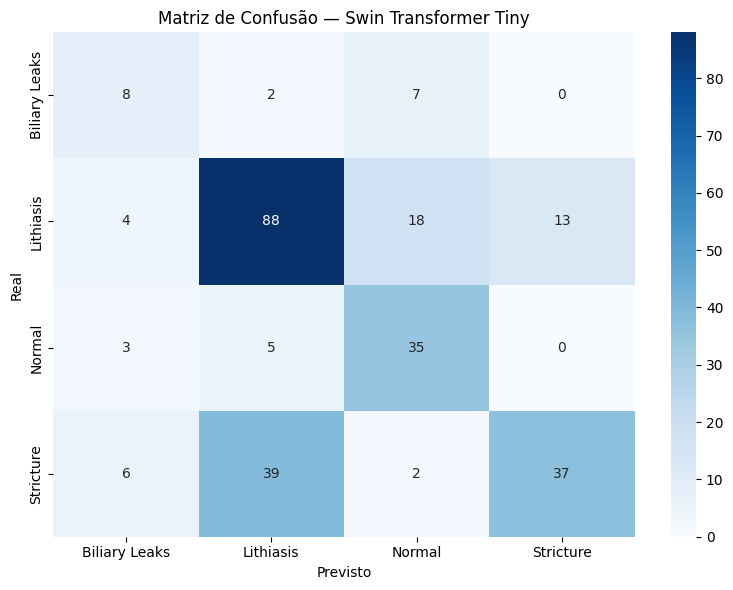

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,███▇▇▇▆▆▅▅▄▃▃▂▁
phase,▁▁▁▁▁███████████████
test_auc_macro,▁
test_f1_macro,▁
train_acc,▁▂▂▃▃▃▄▄▅▅▆▆▇▇▇▇████
train_f1_macro,▁▂▂▂▂▃▄▄▅▆▆▆▇▇▇▇████
train_loss,█▇▇▇▇▇▆▅▄▄▃▃▂▂▂▂▁▁▁▁
val_acc,▁▃▅▄▅▆▅▆▆█▇▇█▇▇▇▇██▇
val_auc_roc,▁▃▆▇█▇▇██▇█▇▇██
+2,...



Treino concluído! Verifica os resultados em https://wandb.ai


In [16]:
trained_model = train_swin(
    wandb_project='saraantunesferreirapinto-universidade-do-minho',
    wandb_entity='saraantunesferreirapinto-universidade-do-minho',
    epochs_phase1=5,
    epochs_phase2=40,
    lr_phase1=1e-3,
    lr_phase2=3e-5,
    patience=10
)


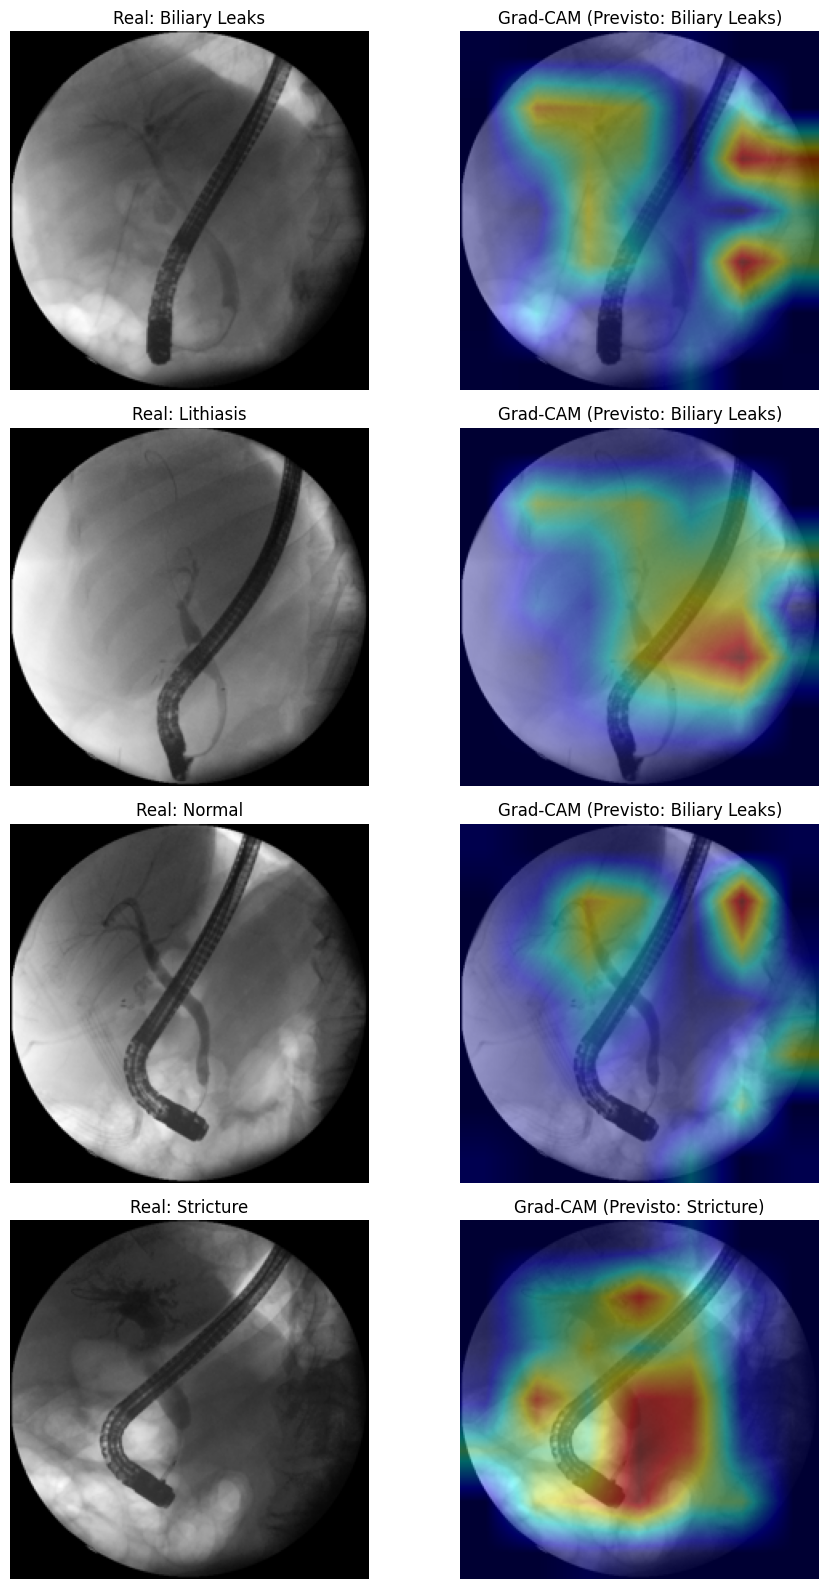

In [21]:
# ── SECÇÃO 8: Visualização e Interpretabilidade (Grad-CAM) ───────────────────
# O Grad-CAM para Vision Transformers foca-se no último estágio de blocos ('norm' ou as últimas camadas de 'layers.3').
# Aqui, extraímos o mapa de ativação correspondente à última camada de atenções para mapear onde a Swin foca.

import cv2

class SwinGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hooks para guardar gradientes e ativações do tensor de features [B, H_patch, W_patch, C]
        self.target_layer.register_forward_hook(self.save_activation)
        # Usamos register_full_backward_hook para compatibilidade e robustez no PyTorch
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
            
        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()
        
        # Swin outputs activations in shape [B, H_patch, W_patch, C] = [1, 7, 7, 768]
        # We need to compute channel weights by averaging gradients over H and W dimensions
        grads = self.gradients[0]  # Shape: [7, 7, 768]
        acts = self.activations[0] # Shape: [7, 7, 768]
        
        # Mean gradients across spatial dimensions (0 and 1) to get channel weights [768]
        weights = torch.mean(grads, dim=[0, 1]) 
        
        # Linear combination of channel weights and activations
        cam = torch.zeros(acts.shape[:2], dtype=torch.float32, device=input_tensor.device) # Shape: [7, 7]
        for i, w in enumerate(weights):
            cam += w * acts[:, :, i]
            
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        # Resize to 224x224 directly
        return cam.detach().cpu().numpy(), class_idx

# Carregar o melhor modelo treinado
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = build_swin(num_classes, freeze_backbone=False)
best_model.load_state_dict(torch.load('./models/swin_tiny_best.pth', map_location=device))

# Inicializar o Grad-CAM visando o último estágio da Swin (layers[-1])
grad_cam = SwinGradCAM(best_model, best_model.layers[-1])

# Escolher 4 imagens do Test Set representativas (uma de cada classe)
representatives = []
for name in class_names:
    sample = df_test[df_test['Label'] == name].head(1)
    if not sample.empty:
        representatives.append(sample.iloc[0])

fig, axes = plt.subplots(len(representatives), 2, figsize=(10, 4 * len(representatives)))

for idx, row in enumerate(representatives):
    img_path = os.path.join(DATA_DIR, row['processed_image_path'])
    orig_img = Image.open(img_path).convert('RGB')
    input_tensor = val_transforms(orig_img).unsqueeze(0).to(device)
    
    # Gerar o heatmap do Grad-CAM (Swin patch mask)
    mask, pred_idx = grad_cam(input_tensor)
    
    # Preparar a imagem original para sobreposição
    orig_np = np.array(orig_img.resize((224, 224)))
    mask_resized = cv2.resize(mask, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Sobreposição (60% imagem original, 40% mapa de calor)
    overlay = cv2.addWeighted(orig_np, 0.6, heatmap, 0.4, 0)
    
    # Plot da Imagem Original
    axes[idx, 0].imshow(orig_np)
    axes[idx, 0].set_title(f"Real: {row['Label']}")
    axes[idx, 0].axis('off')
    
    # Plot do Mapa de Calor Grad-CAM
    axes[idx, 1].imshow(overlay)
    axes[idx, 1].set_title(f"Grad-CAM (Previsto: {class_names[pred_idx]})")
    axes[idx, 1].axis('off')

plt.tight_layout()
# Guardar imagem para o relatório
plt.savefig('./models/swin_gradcam_results.png', dpi=150)
plt.show()

# Log do mapa de calor no WandB para consulta online
wandb.init(
    project='saraantunesferreirapinto-universidade-do-minho',
    entity='saraantunesferreirapinto-universidade-do-minho',
    name='Swin-Grad-CAM-Plots',
    resume="allow"
)
wandb.log({"gradcam_results_plot": wandb.Image(fig)})
wandb.finish()
